# Machine Learning Project
### Spring 2024
## Predicting Credit Card Account Cancellations

<br>
<br>
<p align="center">
<img 
  src="./files/credit_cards.png" 
  alt="Car Accident" 
  width="500"
  height="350"
/>
</p>

<br>

## Credit Card Account Data

The `credit_card_df` data frame contains information on the customers of a large U.S. bank which provides a number of financial services including multiple credit card offerings. 

The bank is looking to see if it can determine the factors that lead to customers canceling their credit card account and whether it can predict if a customer will cancel their account in the future. 

To maintain profits, banks must maximize the number of customers with credit lines. It is also in their best interests for customers to carry large credit card balances from month-to-month to maximize revenue from interest charges.

The bank has experienced record levels of customers closing their credit accounts in the past couple of years and this is leading to declining revenue.

The bank's goal is to become better at identifying customers at risk of canceling their account to minimize financial losses.

Specifically, the broad questions that the company is trying to answer include:

<br>

- What are the factors that are associated with customers closing their credit card accounts?
- Is it possible to predict whether a customer will close their account? If so, how accurate are the predictions?
  - How many costly errors is the model expected to produce?
- Are there any actions or policies the company can implement to reduce the risk of losing their customers?

<br>

The data set contains a mixture of customer demographics and their financial behavior.

The outcome variable in this data is `customer_status`. This variable records whether a customer eventually closed their account and indicates a financial loss to the company.

**Note**: The outcome variable has been coded as a factor with 'closed_account' (**the positive class**) as the first level. This is the format that `tidymodels` expects for calculating model performance metrics. There is no need to recode this variable in your machine learning process.

<br>

### Data Definitions

| Variable            	     | Definition                                 	                | Data Type    |
|:---------------------------|:-------------------------------------------------------------|:-------------|
| customer_status            | Customer status (closed account or active)                   | Factor       |
| age                        | Customer age                                                 | Numeric      |
| dependents                 | Number of dependents in household                            | Numeric      |
| education                  | Customer education level                                     | Factor       |
| marital_status             | Marital status                                               | Factor       |
| employment_status          | Employment status                                            | Factor       |
| income                     | Annual income (US Dollars)                                   | Numeric      |
| card_type                  | Type of credit card                                          | Factor       |
| months_since_first_account | Months since first credit card account activated             | Numeric      |
| total_accounts             | Total accounts (credit checking and savings)                 | Numeric      |
| months_inactive_last_year  | Months without credit card activity last year                | Numeric      |
| contacted_last_year        | Number of times contacted last year by sales representatives | Numeric      |
| credit_limit               | Current credit limit                                         | Numeric      |
| utilization_ratio          | Average monthly balance to credit limit                      | Numeric      |
| spend_ratio_q4_q1          | Ratio of total Q4 to Q1 spending last year                   | Numeric      |
| total_spend_last_year      | Total amount charged last year                               | Numeric      |
| transactions_last_year     | Number of transactions last year                             | Numeric      |
| transaction_ratio_q4_q1    | Ratio of total Q4 to Q1 transactions last year               | Numeric      |

In [ ]:
# Load data
library(tidyverse)
library(ggplot2)

credit_card_df <- readRDS(url('https://gmubusinessanalytics.netlify.app/data/credit_card_df.rds'))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
# View data
credit_card_df

customer_status,age,dependents,education,marital_status,employment_status,income,card_type,months_since_first_account,total_accounts,months_inactive_last_year,contacted_last_year,credit_limit,utilization_ratio,spend_ratio_q4_q1,total_spend_last_year,transactions_last_year,transaction_ratio_q4_q1
<fct>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
closed_account,46,3,masters,married,self_employed,67807,blue,36,2,3,4,4267,0.000,0.862,1067,23,0.769
closed_account,46,3,associates,married,self_employed,51785,blue,34,2,3,2,8583,0.000,0.358,1794,31,0.292
closed_account,44,4,masters,single,part_time,105643,gold,36,5,3,2,2367,0.678,0.956,4506,59,0.639
closed_account,62,1,masters,single,part_time,34138,gold,56,1,2,1,3109,0.000,1.054,5470,72,0.674
closed_account,38,1,masters,married,full_time,36264,blue,20,2,2,3,1621,0.358,0.421,1893,41,0.171
closed_account,43,3,associates,single,part_time,84234,blue,30,3,2,4,11336,0.000,0.691,1809,39,0.345
active,43,2,masters,married,full_time,35379,blue,35,3,1,3,4092,0.152,0.775,5001,88,0.492
closed_account,39,3,associates,married,part_time,67047,blue,29,4,3,4,2187,0.000,0.467,2031,40,0.333
active,54,1,masters,single,full_time,35903,gold,47,6,3,4,12873,0.000,1.005,3170,70,0.842


## Question 1


**Question**: What is the relationship between customer_status and the variables education, marital status, and employment status?  



**Answer**: 
The presented graphs suggest that a significant portion of customers possess educational qualifications at the master’s and associate’s levels, while the majority are classified as either single or married and are engaged in full-time employment. However, it is important to note that while these demographic factors exhibit certain trends, their direct influence on customer status remains inconclusive. This is evidenced by the balanced distribution of closed and active accounts across various demographic categories. For instance, although a considerable number of customers hold master’s and associate’s degrees, the occurrence of closed accounts within the same educational backgrounds is also notable. Therefore, while these demographic attributes may be indicative, they do not definitively determine customer status.

 


## Supporting Analysis

In [ ]:
# This code adjusts the figure output size in the notebook
options(repr.plot.width=11, repr.plot.height=8)

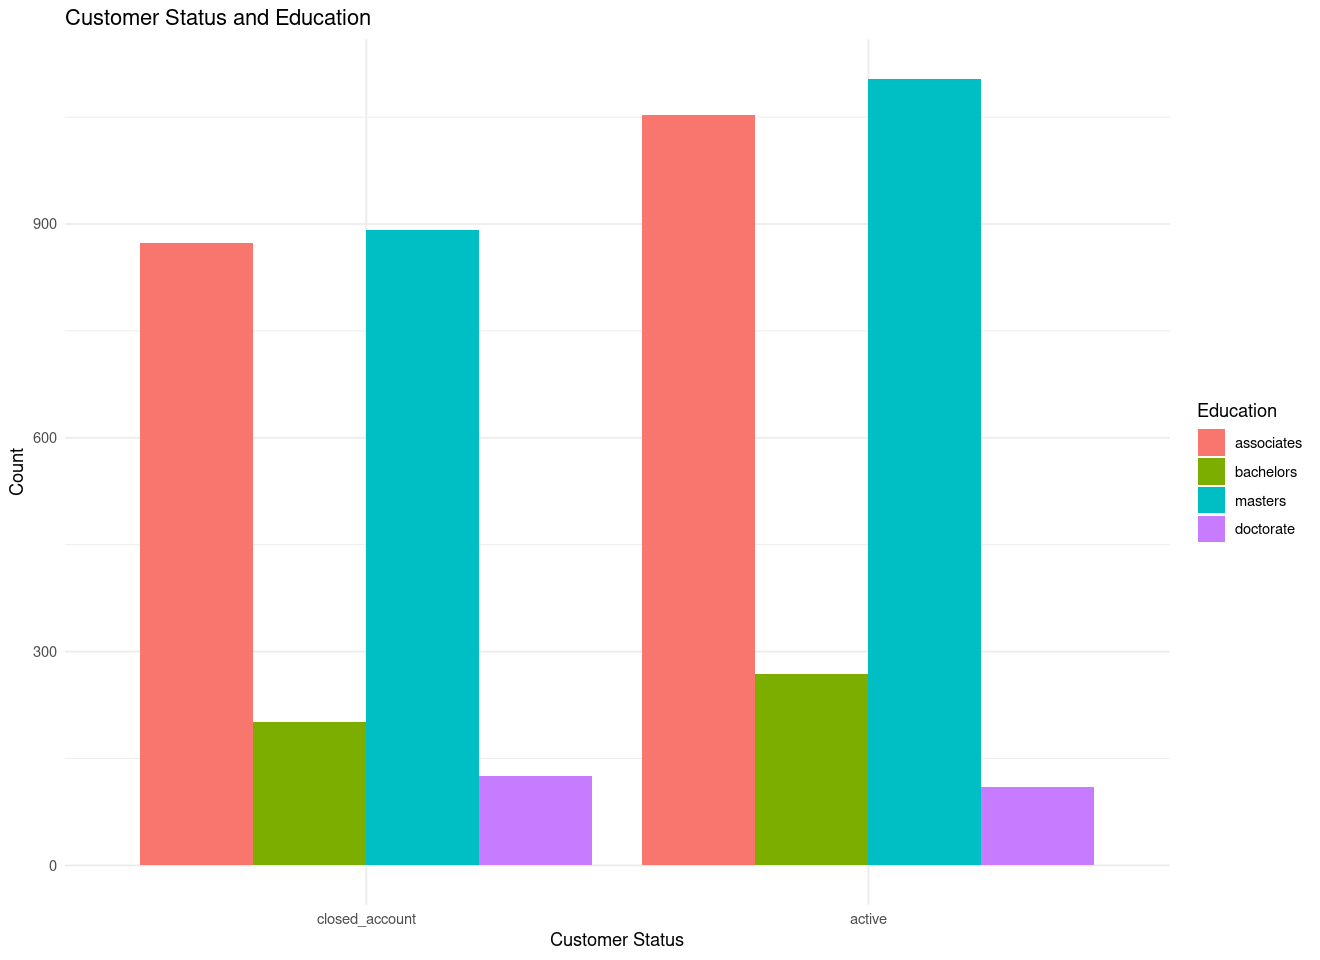

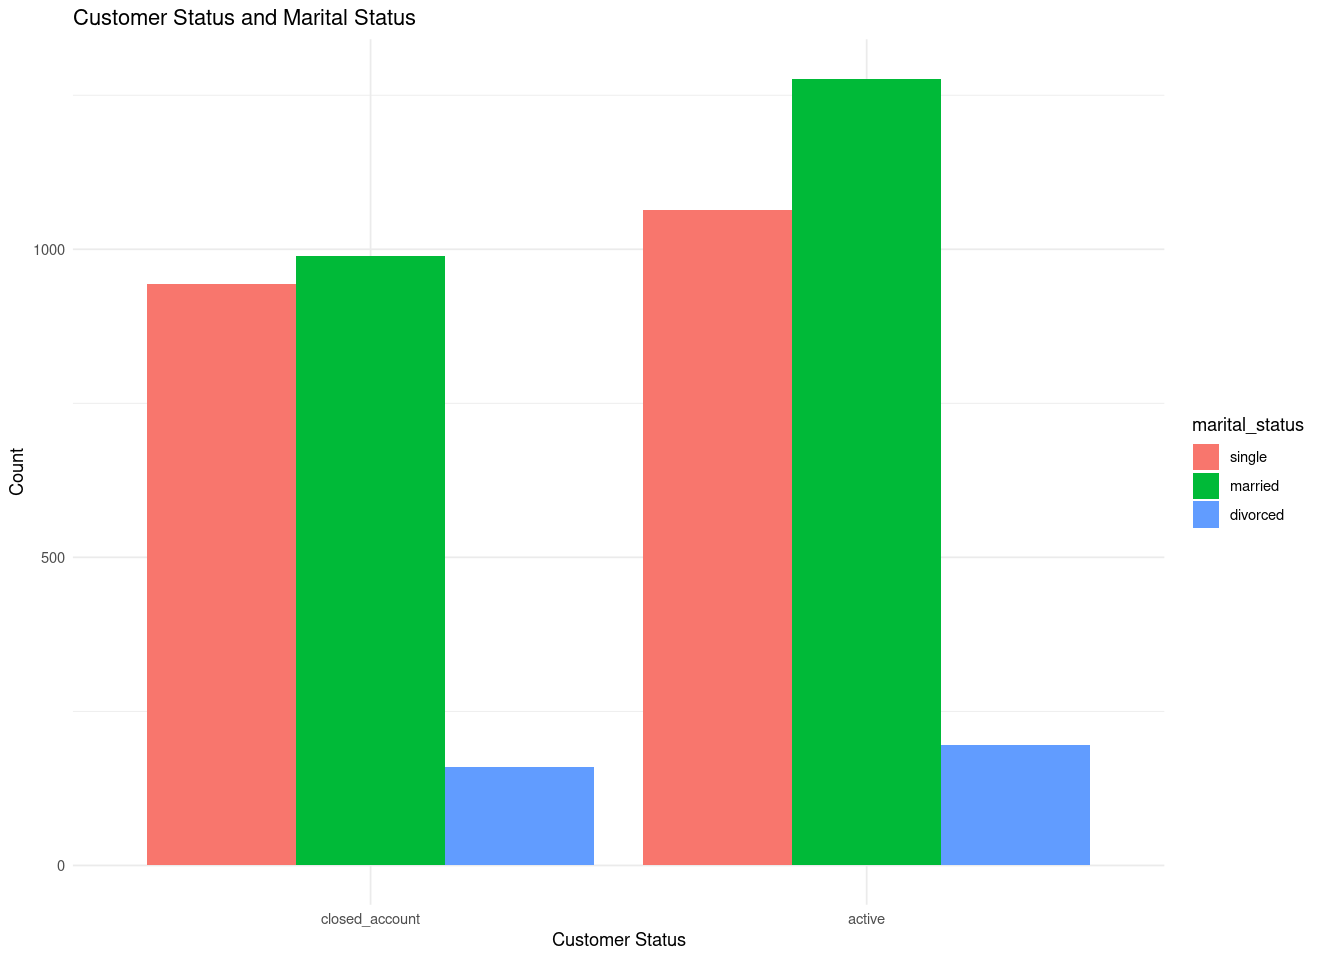

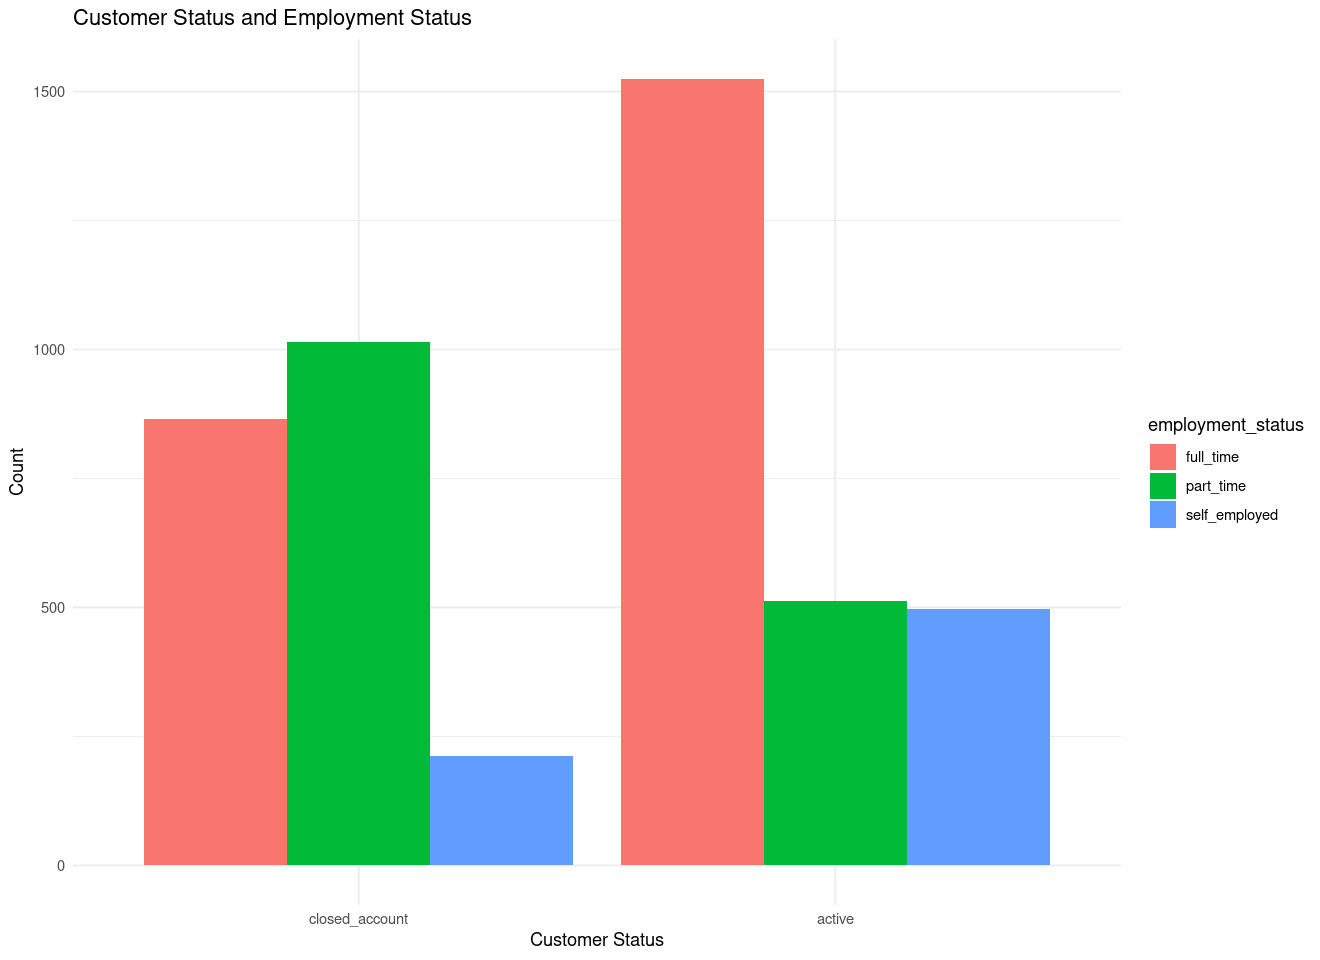

In [ ]:
credit_card_df %>%
  ggplot(aes(x = customer_status, fill = education)) +
  geom_bar(position = "dodge") +
  labs(title = "Customer Status and Education",
       x = "Customer Status",
       y = "Count",
       fill = "Education") +
  theme_minimal()
credit_card_df %>%
  ggplot(aes(x = customer_status, fill = marital_status)) +
  geom_bar(position = "dodge") +
  labs(title = "Customer Status and Marital Status",
       x = "Customer Status",
       y = "Count",
       fill = "marital_status") +
  theme_minimal()
credit_card_df %>%
  ggplot(aes(x = customer_status, fill = employment_status)) +
  geom_bar(position = "dodge") +
  labs(title = "Customer Status and Employment Status",
       x = "Customer Status",
       y = "Count",
       fill = "employment_status") +
  theme_minimal()


## Question 2


**Question**: What factors could contribute to the higher number of closed accounts among customers in different age and income groups?  



**Answer**:
Most of the customers who opted to close their accounts and chose to be active are between the age group 40 to 50 so, age cannot be te individual factor for closing accounts. Additionally, the average income of customers who closed their accounts was 40,000, reflecting a 20,000 difference compared to the average income of customers who chose to keep their accounts open. This suggests that income levels significantly influence customers' decisions regarding their account status.


## Supporting Analysis


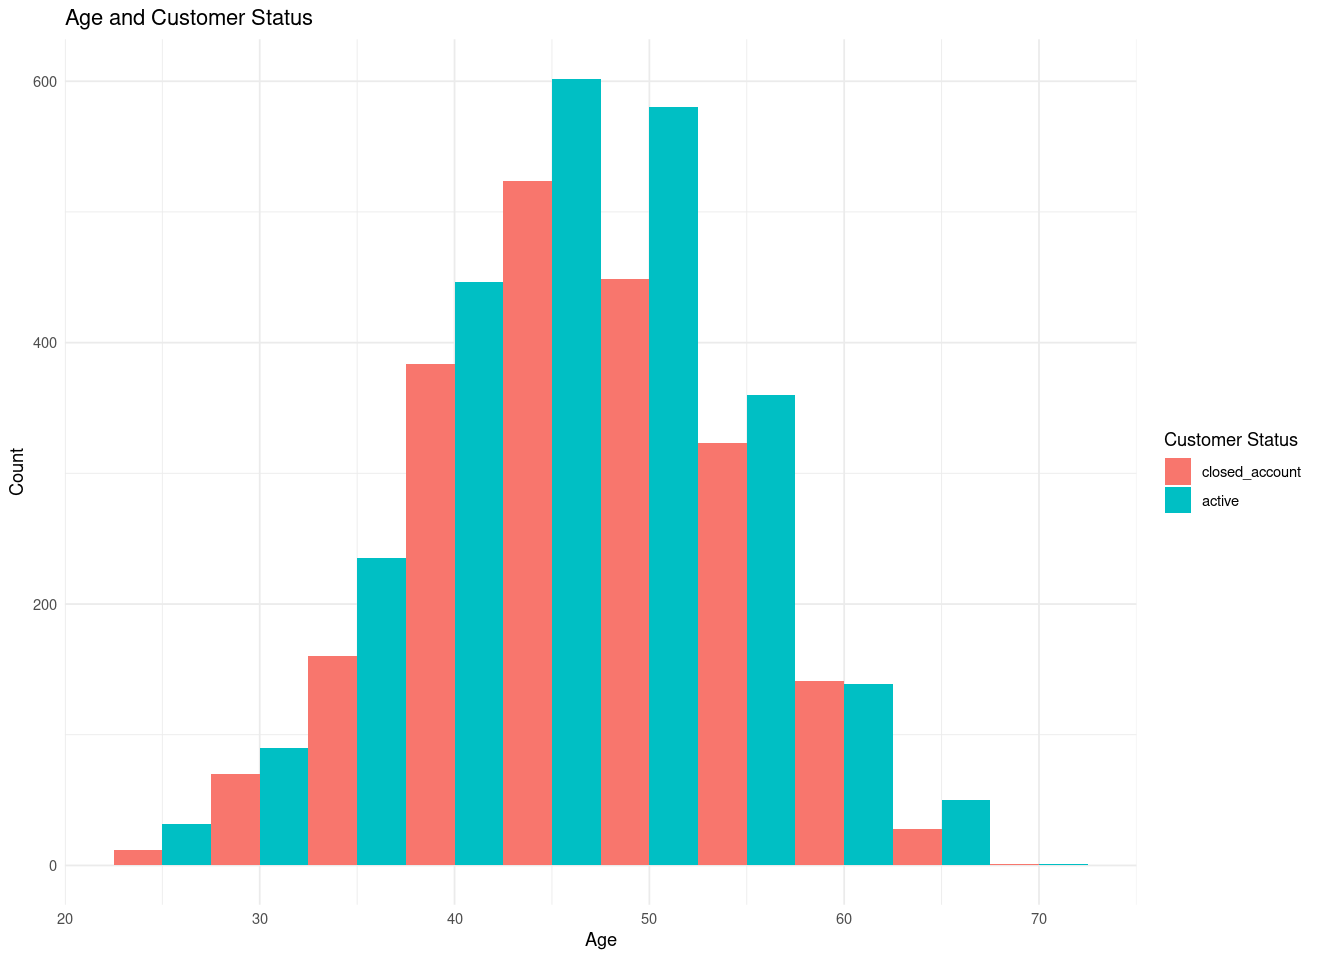

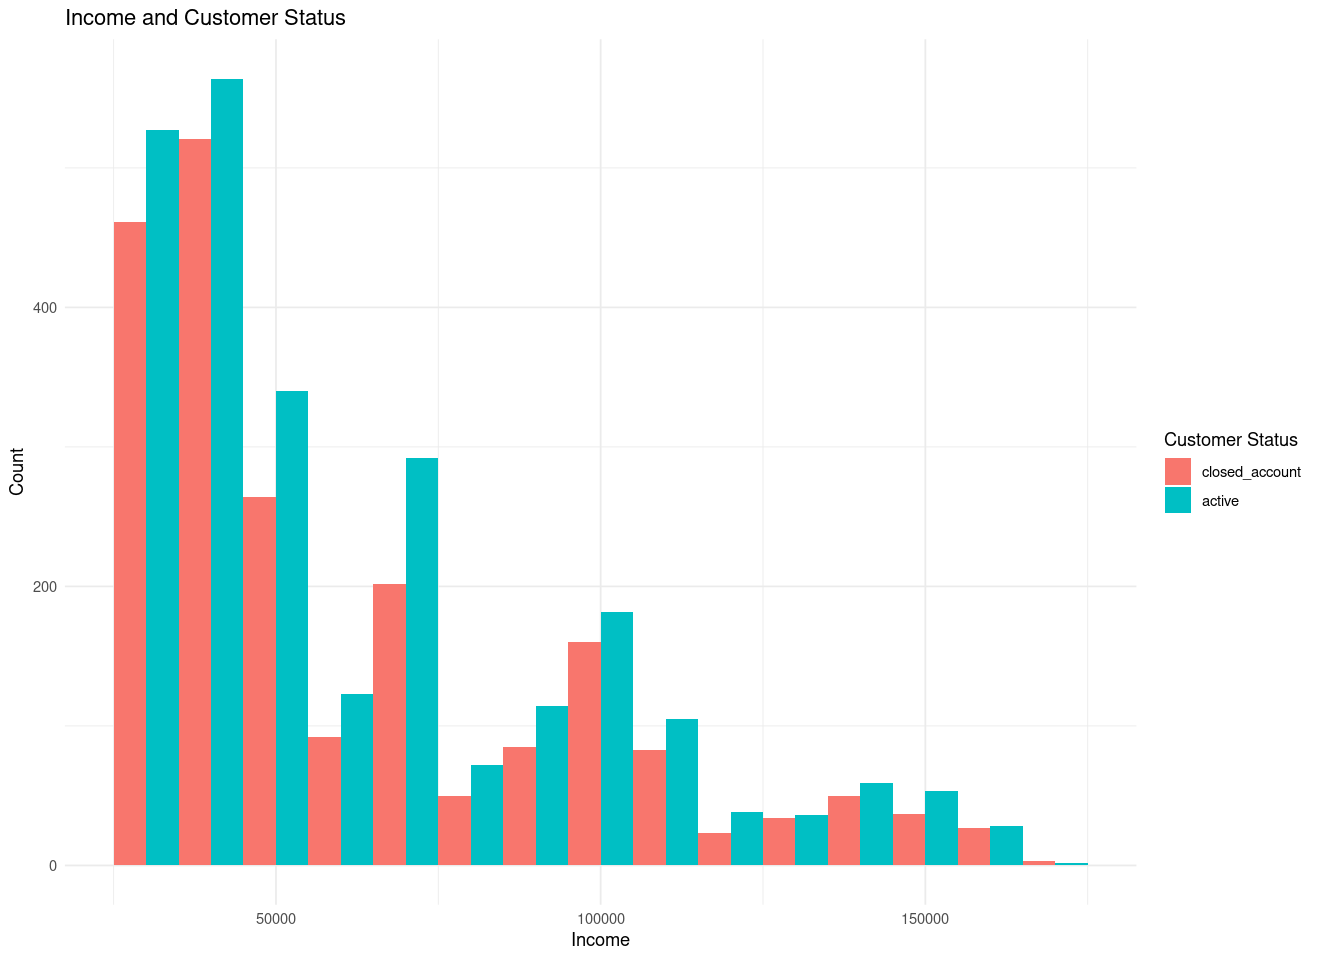

In [ ]:
credit_card_df %>%
  ggplot(aes(x = age, fill = customer_status)) +
  geom_histogram(binwidth = 5, position = "dodge") +
  labs(title = "Age and Customer Status",
       x = "Age",
       y = "Count",
       fill = "Customer Status") +
  theme_minimal()
credit_card_df %>%
  ggplot(aes(x = income, fill = customer_status)) +
  geom_histogram(binwidth = 10000, position = "dodge") +
  labs(title = "Income and Customer Status",
       x = "Income",
       y = "Count",
       fill = "Customer Status") +
  theme_minimal()

## Question 3


**Question**: How does customer status correlate with utilization ratio, and credit limit distributions?



**Answer**:
There is notable difference between the utilization ratios of closed and active customers. Whereas, difference between credit limit s very minimal but considerable between closed and open customers. 
So, we can interpret that active customers tend to have more utilisation ratio and slightly high credit limit.


## Supporting Analysis


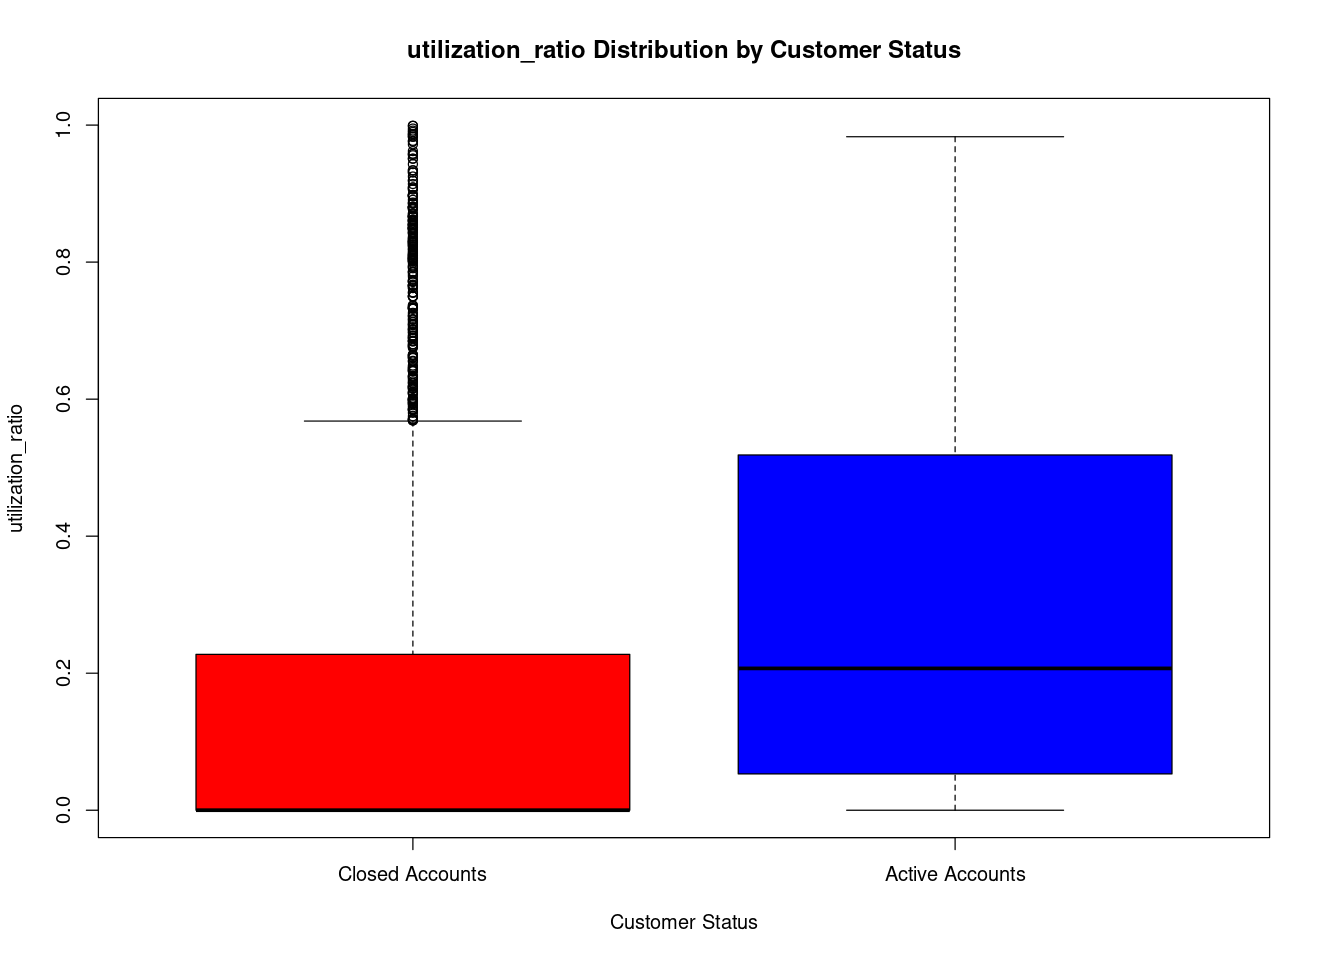

mean_age,mean_income,mean_ur,mean_limit
<dbl>,<dbl>,<dbl>,<dbl>
46.56166,61601.51,0.1610186,8145.746


median_age,median_income,median_ur,median_limit
<dbl>,<dbl>,<dbl>,<dbl>
46,50380,0.207,4798


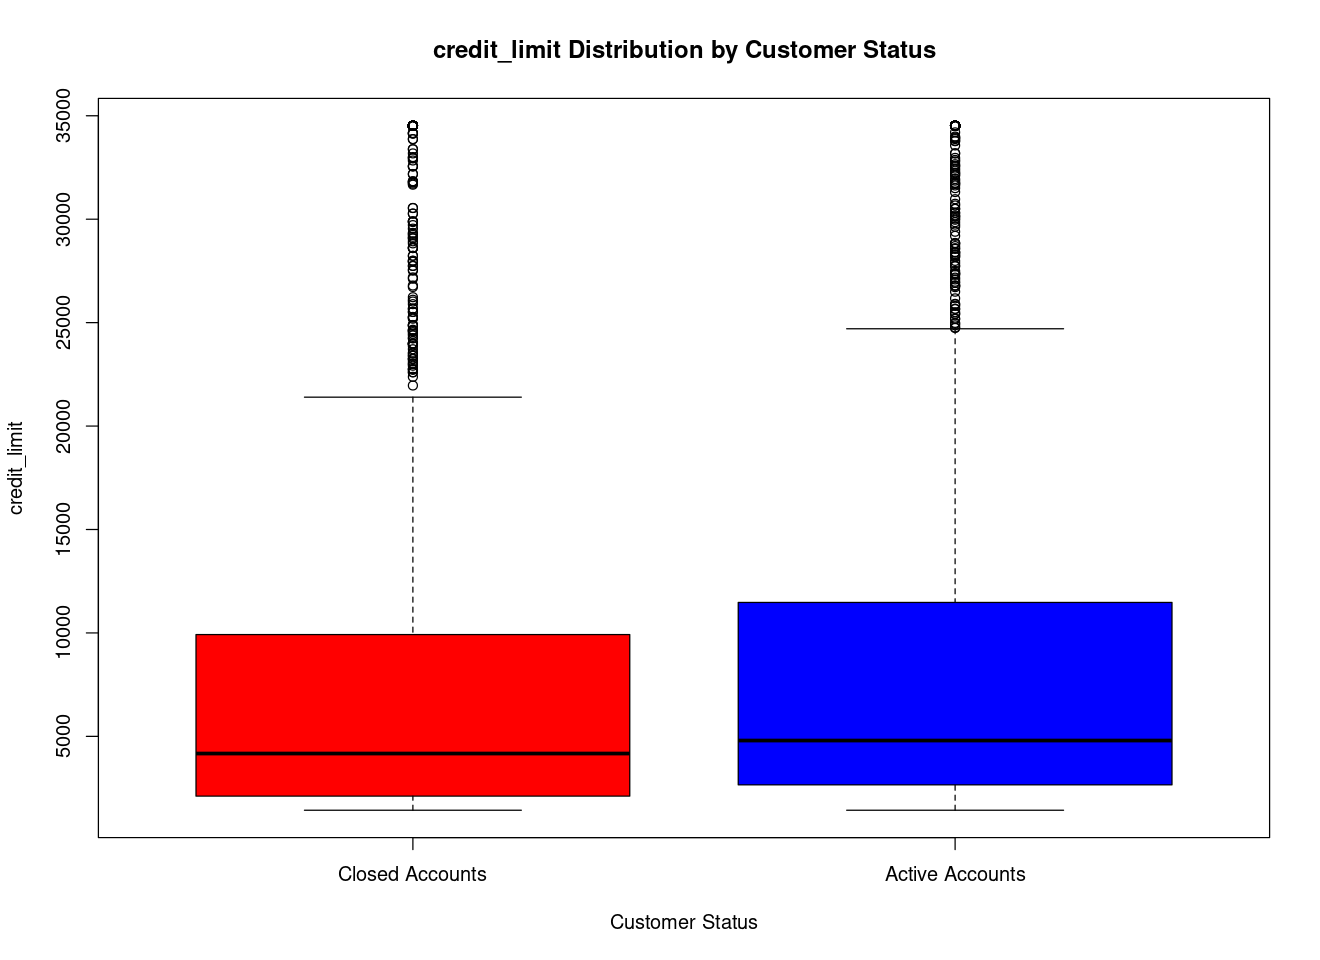

In [ ]:
closed_accounts <- credit_card_df[credit_card_df$customer_status == "closed_account", ]
active_accounts <- credit_card_df[credit_card_df$customer_status == "active", ]


boxplot(closed_accounts$utilization_ratio, active_accounts$utilization_ratio, 
        names = c("Closed Accounts", "Active Accounts"),
        xlab = "Customer Status",
        ylab = "utilization_ratio",
        col = c("red", "blue"),
        main = "utilization_ratio Distribution by Customer Status")

boxplot(closed_accounts$credit_limit, active_accounts$credit_limit, 
        names = c("Closed Accounts", "Active Accounts"),
        xlab = "Customer Status",
        ylab = "credit_limit",
        col = c("red", "blue"),
        main = "credit_limit Distribution by Customer Status")

df_closed <- closed_accounts %>%
			
			summarise (
                      	mean_age = mean(age),
                       mean_income = mean(income),
                       mean_ur = mean(utilization_ratio),
                       	mean_limit = mean(credit_limit)
                      )
df_closed

df_active <- active_accounts %>%
			
			summarise (
                      	median_age = median(age),
                       median_income = median(income),
                       median_ur = median(utilization_ratio),
                       	median_limit = median(credit_limit)
                      )
df_active

## Question 4


**Question**: How does the credit limit correlate with factors such as education level, employment status, and income?



**Answer**:
From the below bubble chart it can be interpreted that:
Self-Employes individuals with a doctorate have higher mean income but a lower credit limit compared to other customers with other degrees who are self employed.
Part-time workers with a bachelor’s degree have a moderate mean income and credit limit.
Full-time employees with a master’s degree exhibit a higher mean credit limit and a moderate income.
Those with a bachelor’s degree also have a reasonable mean credit limit and income.

## Supporting Analysis


education,mean_credit_limit,mean_income
<fct>,<dbl>,<dbl>
associates,8737.792,63225.15
bachelors,8520.439,63198.62
masters,8363.879,61433.95
doctorate,7688.064,59920.26


`summarise()` has grouped output by 'education'. You can override using the
`.groups` argument.


education,employment_status,mean_credit_limit,mean_income
<fct>,<fct>,<dbl>,<dbl>
associates,full_time,8630.220,62183.72
associates,part_time,9076.460,64722.44
associates,self_employed,8357.301,63565.56
bachelors,full_time,8580.835,62398.58
bachelors,part_time,8485.297,65555.27
bachelors,self_employed,8407.538,60936.17
masters,full_time,8373.219,63432.42
masters,part_time,8469.113,59039.68
masters,self_employed,8117.307,59981.29


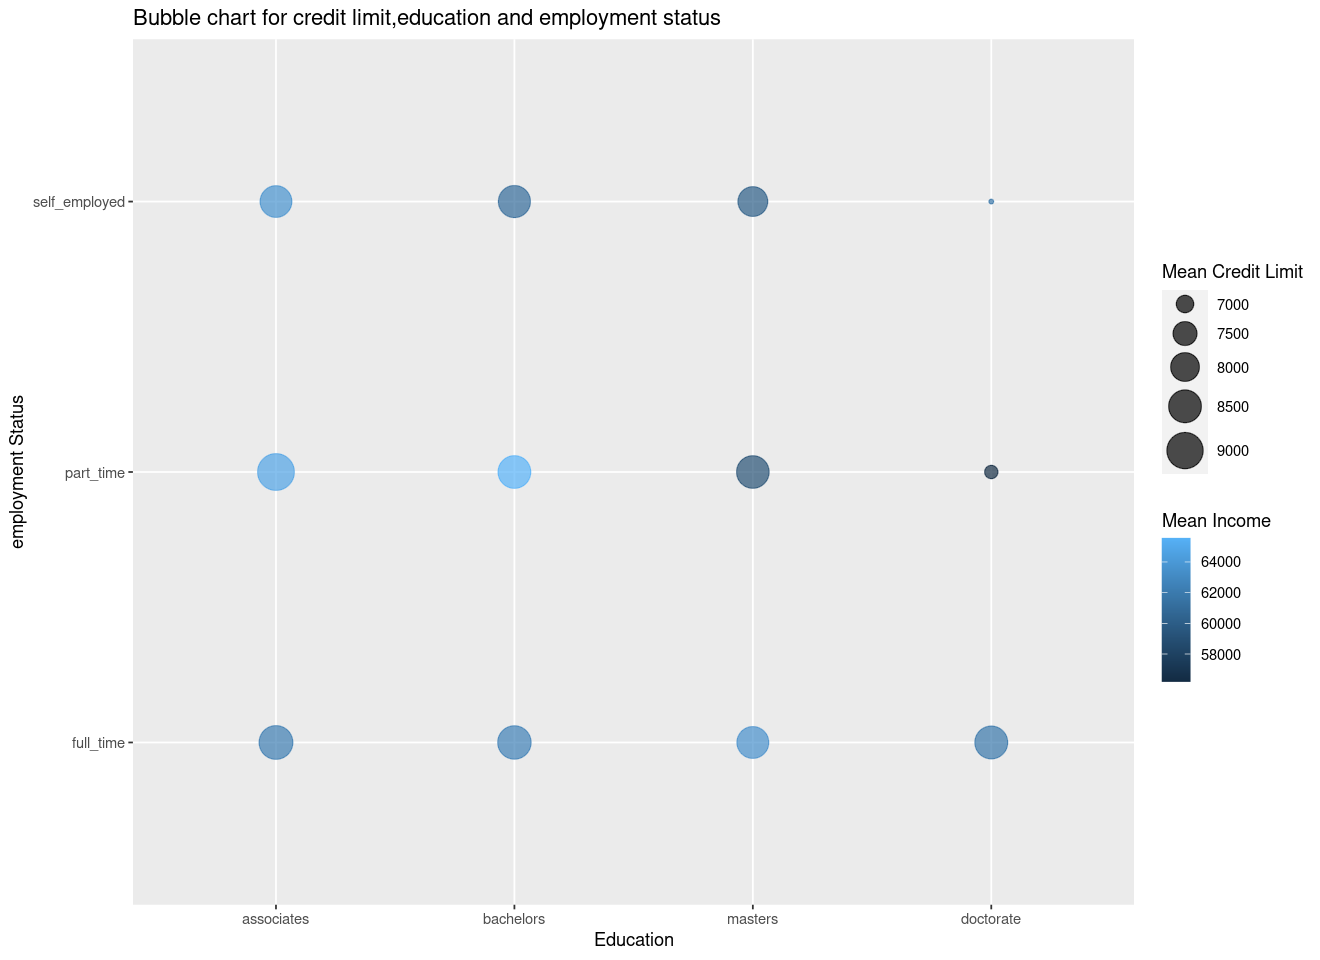

In [ ]:
A3 <- credit_card_df %>% select(credit_limit,income,education, employment_status)%>% group_by(education) %>% summarise(mean_credit_limit=mean(credit_limit),mean_income=mean(income))
View(A3)

A4<-credit_card_df %>% select(credit_limit,income,education, employment_status)%>% group_by(education,employment_status) %>% summarise(mean_credit_limit=mean(credit_limit),mean_income=mean(income))
View(A4)
ggplot(A4,aes(x=education,y=employment_status,size=mean_credit_limit,color=mean_income))+
  geom_point(alpha=0.7)+
  scale_size_continuous(range=c(1,10))+
  labs(title="Bubble chart for credit limit,education and employment status",x="Education",y="employment Status",size="Mean Credit Limit",color="Mean Income")


## Question 5


**Question**: Is there an evident relationship between customer status and their total spending last year, as well as their credit limit? 



**Answer**:

The scatter plot analysis indicates distinct patterns between closed and active account holders based on their credit limits and total spending from the past year. Closed account holders, represented by red dots, predominantly cluster towards the lower end of both axes, indicating lower credit limits and reduced spending. Conversely, active account holders, depicted by blue dots, exhibit a more dispersed distribution across various credit limits and spending levels. Notably, there is a notable concentration of blue dots at higher credit limit values, suggesting a subgroup of active account holders with elevated credit limits. Overall, the scatter plot underscores that active account holders display greater variability in both credit limits and spending behavior, whereas closed account holders tend to have lower credit limits and less spending.
The customers with total spendings more than 10000 are active customers of the credit card.



## Supporting Analysis


customer_status,mean_credit_limit,mean_total_spend_last_year
<fct>,<dbl>,<dbl>
closed_account,8145.746,3120.827
active,8794.175,4596.663


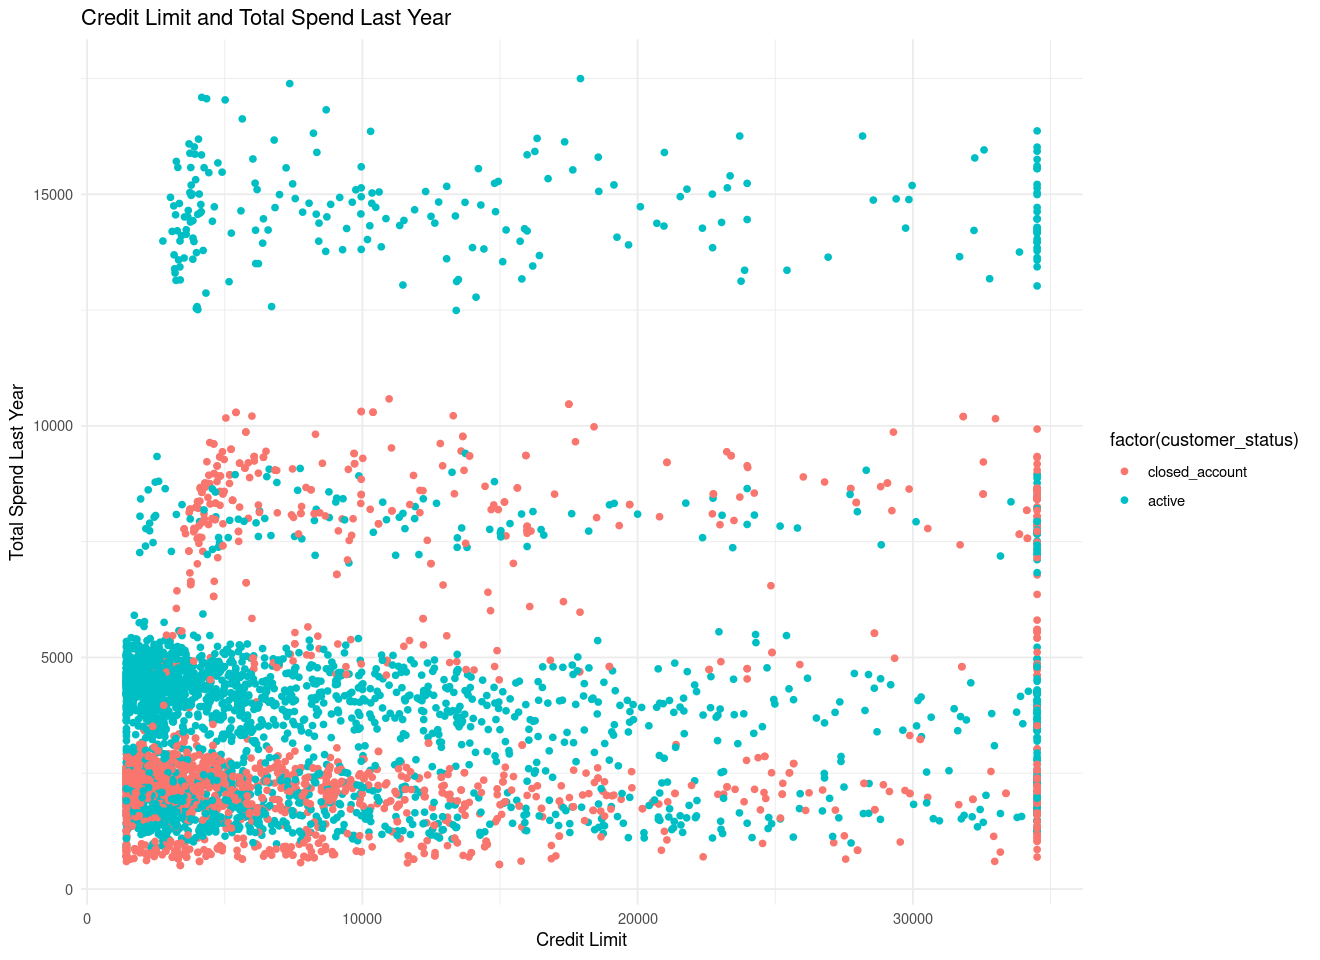

In [ ]:

A5<-credit_card_df%>%select(credit_limit,total_spend_last_year,customer_status)%>%group_by(customer_status)%>%summarise(mean_credit_limit=mean(credit_limit),mean_total_spend_last_year=mean(total_spend_last_year))
View(A5)
credit_card_df %>%
  ggplot(aes(x = credit_limit, y = total_spend_last_year)) +
  geom_point(aes(color = factor(customer_status))) +
   
 
  labs(title = "Credit Limit and Total Spend Last Year",
       x = "Credit Limit",
       y = "Total Spend Last Year") + 
  theme_minimal() 

# Machine Learning Modeling 


In [ ]:
# Run this R code to install ML packages that you might need (Will take about 1 minute)
install.packages('vip')

Retrieving 'https://packagemanager.rstudio.com/all/__linux__/focal/latest/src/contrib/vip_0.4.1.tar.gz' ...
	OK [downloaded 2.4 Mb in 0.1 secs]
Installing vip [0.4.1] ...
	OK [installed binary]
Moving vip [0.4.1] into the cache ...
	OK [moved to cache in 0.36 milliseconds]


## Data Resampling
First split your data into training and test sets. If performing hyperparameter tuning, also create folds from your training data

In [ ]:
library(tidymodels)
library(vip)
set.seed(345)
credit_card_df$customer_status <- factor(credit_card_df$customer_status)

credit_split <- 
  initial_split(credit_card_df, prop = 0.75, strata = customer_status)

credit_training <- 
  credit_split %>% 
  training()

credit_test <- 
  credit_split %>% 
  testing()

── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.5     ✔ rsample      1.2.0
✔ dials        1.2.0     ✔ tune         1.1.2
✔ infer        1.0.5     ✔ workflows    1.1.3
✔ modeldata    1.2.0     ✔ workflowsets 1.0.1
✔ parsnip      1.1.1     ✔ yardstick    1.2.0
✔ recipes      1.0.9     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()
• Search for functions across packages at https://www.tidymodels.org/find/


Attaching package: ‘vip’


The following object is masked from ‘package:utils’:

    vi




## Feature Engineering Pipeline
Specify your feature engineering pipeline with the `recipes` package. You will use the pipeline when you create your modeling workflows below for each of your models.

In [ ]:
credit_recipe <-
  recipe(customer_status ~ ., data = credit_training) %>% 
  step_YeoJohnson(all_numeric(), -all_outcomes()) %>% 
  step_normalize(all_numeric(), -all_outcomes()) %>% 
  step_dummy(all_nominal(), -all_outcomes())

In [ ]:
credit_recipe %>% 
  prep(training = credit_training) %>% 
  bake(new_data = NULL)

age,dependents,income,months_since_first_account,total_accounts,months_inactive_last_year,contacted_last_year,credit_limit,utilization_ratio,spend_ratio_q4_q1,⋯,customer_status,education_bachelors,education_masters,education_doctorate,marital_status_married,marital_status_divorced,employment_status_part_time,employment_status_self_employed,card_type_silver,card_type_gold
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
-0.43279456,-0.2881061,-0.99083467,-0.15302761,-0.3954397,-1.5794583,0.3010761,-0.16025406,0.04652617,0.231974774,⋯,active,0,1,0,1,0,0,0,0,0
0.97813111,-1.0638666,-0.94348105,1.42418747,1.4424668,0.5854826,1.1707435,0.99072869,-1.04489801,1.182665510,⋯,active,0,1,0,0,0,0,0,0,1
-0.30554488,0.4742263,-0.81625083,-0.77904428,1.4424668,0.5854826,0.3010761,-0.04068920,1.08780787,-0.084861722,⋯,active,1,0,0,0,0,0,0,0,0
2.01814692,-0.2881061,-0.91116117,1.97045826,1.4424668,-0.4168643,1.1707435,-0.54514796,1.26894359,0.694480624,⋯,active,0,1,0,1,0,0,1,1,0
0.07747858,0.4742263,0.66114859,-0.02545648,-1.0455122,0.5854826,-1.5104681,0.92418358,0.27158588,0.522463292,⋯,active,0,0,0,1,0,0,0,0,1
0.71985948,1.2267268,-0.90043534,1.55986260,0.8444977,2.3058982,-0.5899284,-1.58467355,1.25020202,-0.334544260,⋯,active,0,0,0,0,1,0,0,0,0
-0.68662985,0.4742263,-1.00999510,-0.65548113,-1.0455122,-0.4168643,-0.5899284,-0.16197076,1.15199343,0.231974774,⋯,active,1,0,0,1,0,0,0,0,0
-1.06564851,-1.0638666,1.28303890,-1.38347974,0.2329186,-0.4168643,1.1707435,0.57291555,-1.04489801,-0.608241764,⋯,active,0,1,0,0,0,0,0,1,0
-1.56753565,-0.2881061,-1.13787805,-2.18706199,0.2329186,-1.5794583,0.3010761,-0.66082224,-1.04489801,-0.353749140,⋯,active,0,1,0,1,0,0,0,1,0


## Model 1 Training(Logistic Regression)

In [ ]:
logistic_model <- 
  logistic_reg() %>% 
  set_engine('glm') %>% 
  set_mode('classification') 
credit_wf <-
  workflow() %>% 
  add_model(logistic_model) %>% 
  add_recipe(credit_recipe)
credit_logistic_fit <- 
  credit_wf %>% 
  fit(data = credit_training)
credit_trained_model <- 
  credit_logistic_fit %>% 
  extract_fit_parsnip()

## Model 1 Performance Evaluation(Logistic Regression)

In [ ]:
predictions_categories <- 
  predict(credit_logistic_fit, new_data = credit_test)

predictions_categories

predictions_probabilities <- 
  predict(credit_logistic_fit, new_data = credit_test, type = 'prob')

predictions_probabilities


test_results <- 
  credit_test %>% 
  select(customer_status) %>% 
  bind_cols(predictions_categories) %>% 
  bind_cols(predictions_probabilities)

test_results

.pred_class
<fct>
closed_account
active
closed_account
active
closed_account
closed_account
closed_account
closed_account
active


.pred_closed_account,.pred_active
<dbl>,<dbl>
0.9683384465,0.031661554
0.2773625628,0.722637437
0.5753208155,0.424679184
0.0004662092,0.999533791
0.9820605654,0.017939435
0.6163246770,0.383675323
0.9969837346,0.003016265
0.9669213379,0.033078662
0.0509191275,0.949080873


customer_status,.pred_class,.pred_closed_account,.pred_active
<fct>,<fct>,<dbl>,<dbl>
closed_account,closed_account,0.9683384465,0.031661554
closed_account,active,0.2773625628,0.722637437
closed_account,closed_account,0.5753208155,0.424679184
active,active,0.0004662092,0.999533791
closed_account,closed_account,0.9820605654,0.017939435
active,closed_account,0.6163246770,0.383675323
closed_account,closed_account,0.9969837346,0.003016265
closed_account,closed_account,0.9669213379,0.033078662
active,active,0.0509191275,0.949080873


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.8833189


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
sens,binary,0.8776291


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
spec,binary,0.8880126


.threshold,specificity,sensitivity
<dbl>,<dbl>,<dbl>
-Inf,0.000000000,1
0.0002468732,0.000000000,1
0.0002978616,0.001577287,1
0.0004339938,0.003154574,1
0.0004662092,0.004731861,1
0.0005130623,0.006309148,1
0.0005691473,0.007886435,1
0.0008096502,0.009463722,1
0.0008136334,0.011041009,1


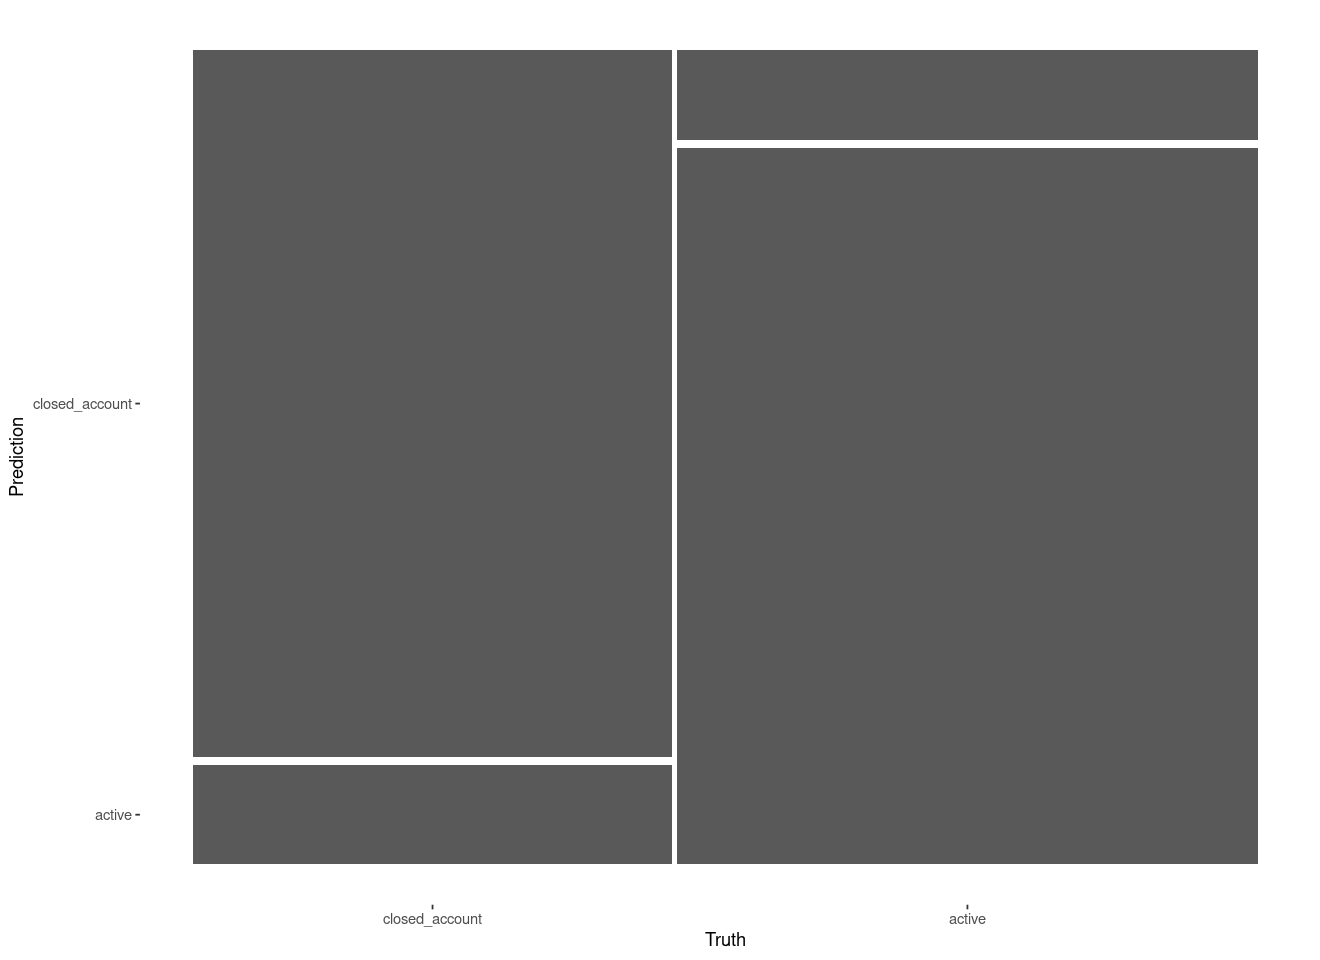

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
roc_auc,binary,0.9545572


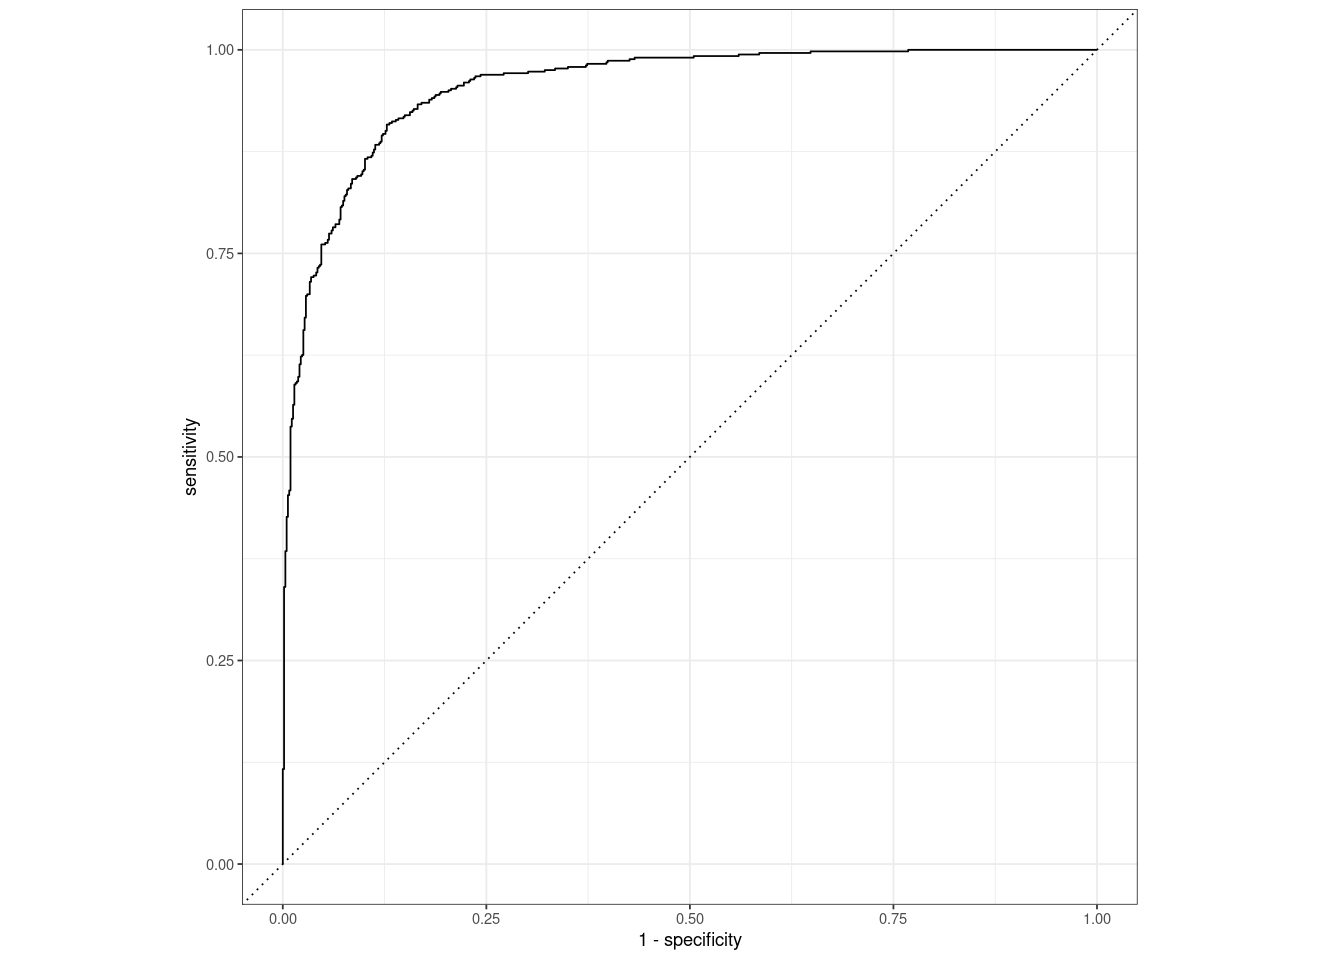

In [ ]:
accuracy(test_results, truth = customer_status,
    estimate = .pred_class)

conf_mat(test_results, 
         truth = customer_status, 
         estimate = .pred_class) %>% 
autoplot()


sens(test_results,
     truth = customer_status, 
     estimate = .pred_class)

spec(test_results,
     truth = customer_status, 
     estimate = .pred_class)

roc_curve(test_results, 
          truth = customer_status,
          .pred_closed_account)

roc_curve(test_results, 
          truth = customer_status, 
          .pred_closed_account) %>% 
  autoplot()

roc_auc(test_results, 
          truth = customer_status, 
          .pred_closed_account)
 

## Model 2 Training(K-Nearest Neighbour)

In [ ]:
set.seed(314)
credit_folds <- vfold_cv(credit_training, v = 5)

knn_model <- 
  nearest_neighbor(neighbors = tune()) %>% 
  set_engine('kknn') %>% 
  set_mode('classification')

knn_wf <- 
  workflow() %>% 
  add_model(knn_model) %>% 
  add_recipe(credit_recipe)



knn_tuning <- 
  knn_wf %>% 
  tune_grid(resamples = credit_folds, grid = 10)

knn_tuning %>% show_best('roc_auc')

best_k <- 
  knn_tuning %>% 
  select_best(metric = 'roc_auc')

best_k

neighbors,.metric,.estimator,mean,n,std_err,.config
<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
14,roc_auc,binary,0.9161865,5,0.002019804,Preprocessor1_Model10
13,roc_auc,binary,0.9150632,5,0.001842274,Preprocessor1_Model09
12,roc_auc,binary,0.9138338,5,0.001834158,Preprocessor1_Model08
10,roc_auc,binary,0.9110943,5,0.001668841,Preprocessor1_Model07
9,roc_auc,binary,0.9093766,5,0.001790483,Preprocessor1_Model06


neighbors,.config
<int>,<chr>
14,Preprocessor1_Model10


In [ ]:
final_knn_wf <- 
  knn_wf %>% 
  finalize_workflow(best_k)



## Model 2 Performance Evaluation(K-Nearest Neighbour)

.metric,.estimator,.estimate,.config
<chr>,<chr>,<dbl>,<chr>
accuracy,binary,0.8539326,Preprocessor1_Model1
roc_auc,binary,0.9207964,Preprocessor1_Model1


id,.pred_closed_account,.pred_active,.row,.pred_class,customer_status,.config
<chr>,<dbl>,<dbl>,<int>,<fct>,<fct>,<chr>
train/test split,0.781564867,0.21843513,1,closed_account,closed_account,Preprocessor1_Model1
train/test split,0.468243033,0.53175697,3,active,closed_account,Preprocessor1_Model1
train/test split,0.503756864,0.49624314,4,closed_account,closed_account,Preprocessor1_Model1
train/test split,0.030956466,0.96904353,10,active,active,Preprocessor1_Model1
train/test split,0.930112993,0.06988701,13,closed_account,closed_account,Preprocessor1_Model1
train/test split,0.686559089,0.31344091,14,closed_account,active,Preprocessor1_Model1
train/test split,1.000000000,0.00000000,17,closed_account,closed_account,Preprocessor1_Model1
train/test split,0.716715218,0.28328478,22,closed_account,closed_account,Preprocessor1_Model1
train/test split,0.000000000,1.00000000,23,active,active,Preprocessor1_Model1


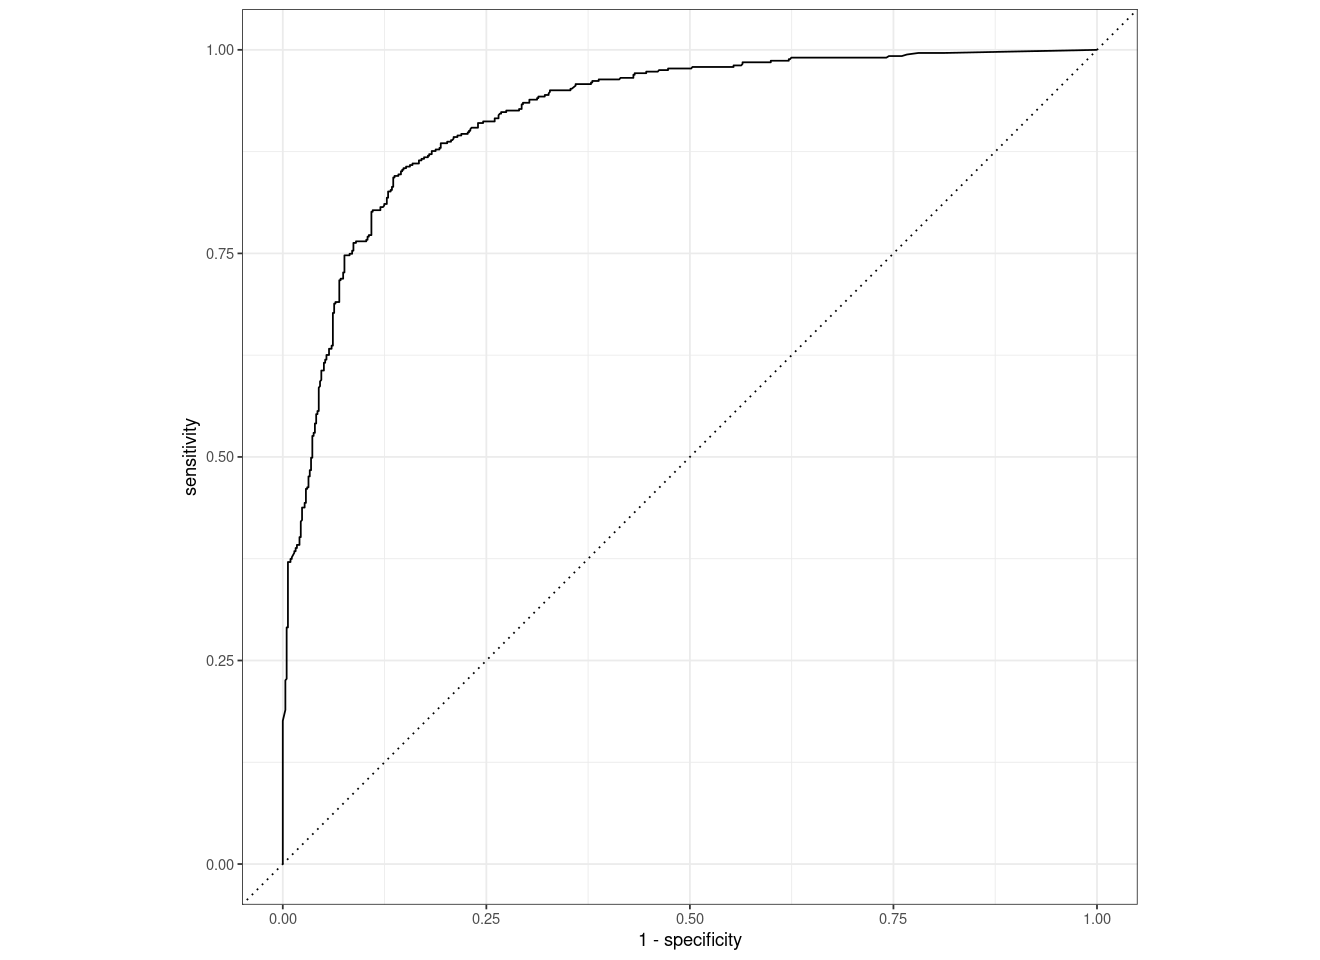

In [ ]:
last_fit_knn <- final_knn_wf %>% 
                last_fit(split = credit_split)

last_fit_knn %>% collect_metrics()

knn_predictions <- 
  last_fit_knn %>% 
  collect_predictions()

knn_predictions

knn_predictions %>% 
  roc_curve(truth = customer_status, .pred_closed_account) %>% 
  autoplot()



## Model 3 Training(Decision Tree)

In [ ]:
tree_model <- 
  decision_tree(cost_complexity = tune(),
                tree_depth = tune(),
                min_n = tune()) %>% 
  set_engine('rpart') %>% 
  set_mode('classification')

tree_workflow <- 
  workflow() %>% 
  add_model(tree_model) %>% 
  add_recipe(credit_recipe)


tree_grid <- 
  grid_regular(cost_complexity(),
               tree_depth(),
               min_n(), 
               levels = 2)
tree_grid

tree_grid <- 
  grid_regular(extract_parameter_set_dials(tree_model), levels = 2)
tree_grid



tree_tuning <- 
  tree_workflow %>% 
  tune_grid(resamples = credit_folds, grid = tree_grid)


tree_tuning %>% show_best('roc_auc')

cost_complexity,tree_depth,min_n
<dbl>,<int>,<int>
1e-10,1,2
1e-01,1,2
1e-10,15,2
1e-01,15,2
1e-10,1,40
1e-01,1,40
1e-10,15,40
1e-01,15,40


cost_complexity,tree_depth,min_n
<dbl>,<int>,<int>
1e-10,1,2
1e-01,1,2
1e-10,15,2
1e-01,15,2
1e-10,1,40
1e-01,1,40
1e-10,15,40
1e-01,15,40


cost_complexity,tree_depth,min_n,.metric,.estimator,mean,n,std_err,.config
<dbl>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1e-10,15,40,roc_auc,binary,0.9426542,5,0.001043348,Preprocessor1_Model7
1e-10,15,2,roc_auc,binary,0.9116503,5,0.005308986,Preprocessor1_Model3
1e-10,1,2,roc_auc,binary,0.7625460,5,0.006761450,Preprocessor1_Model1
1e-01,1,2,roc_auc,binary,0.7625460,5,0.006761450,Preprocessor1_Model2
1e-01,15,2,roc_auc,binary,0.7625460,5,0.006761450,Preprocessor1_Model4


In [ ]:

best_tree <- 
  tree_tuning %>% 
  select_best(metric = 'roc_auc')


best_tree

final_tree_workflow <- 
  tree_workflow %>% 
  finalize_workflow(best_tree)

tree_wf_fit <- 
  final_tree_workflow %>% 
  fit(data = credit_training)

tree_fit <- 
  tree_wf_fit %>% 
  extract_fit_parsnip()

cost_complexity,tree_depth,min_n,.config
<dbl>,<int>,<int>,<chr>
1e-10,15,40,Preprocessor1_Model7


## Model 3 Performance Evaluation(Decision Tree)

In [ ]:
tree_last_fit <- 
  final_tree_workflow %>% 
  last_fit(credit_split)

tree_last_fit %>% collect_metrics()


.metric,.estimator,.estimate,.config
<chr>,<chr>,<dbl>,<chr>
accuracy,binary,0.9049265,Preprocessor1_Model1
roc_auc,binary,0.9504949,Preprocessor1_Model1


                Truth
Prediction       closed_account active
  closed_account            490     77
  active                     33    557

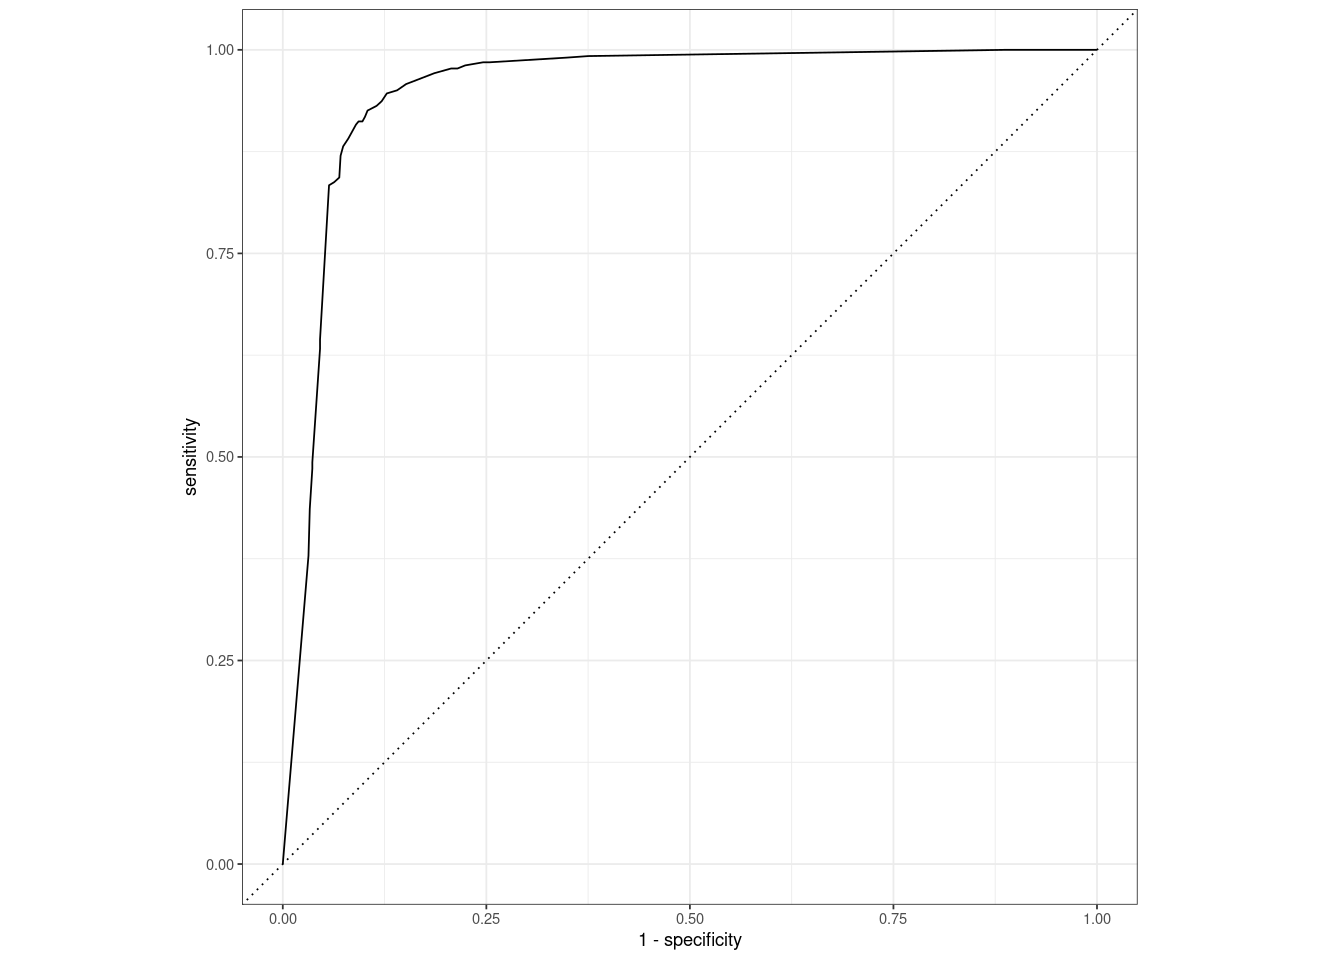

In [ ]:
tree_last_fit %>% 
collect_predictions() %>% 
roc_curve(truth  = customer_status, .pred_closed_account) %>% 
autoplot()

tree_predictions <- tree_last_fit %>% collect_predictions()

conf_mat(tree_predictions, truth = customer_status, estimate = .pred_class)

# Executive Summary (25 Points)

Write an executive summary of your overall findings and recommendations to the executives at the bank. Think of this section as your closing remarks of a presentation, where you summarize your key findings, model performance, and make recommendations to improve customer retention and service at the ban

Your executive summary must be written in a [professional tone](https://www.universalclass.com/articles/writing/business-writing/appropriate-tone-in-business-communications.htm), with minimal grammatical errors, and should include the following sections:

1.  An introduction where you explain the business problem and goals of your data analysis

- What problem(s) is this company trying to solve? Why are they important to their future success?
- What was the goal of your analysis? What questions were you trying to answer and why do they matter?

2.  Highlights and key findings from your Exploratory Data Analysis section

- What were the interesting findings from your analysis and **why are they important for the business**?
- This section is meant to **establish the need for your recommendations** 
        in the following section

3. Your “best” classification model and an analysis of its performance 
	- In this section you should talk about the expected error of your model on future data
	 	- To estimate future performance, you can use your model performance results on the **test data**
    - You should discuss at least one performance metric, such as an F1, sensitivity, specificity, or ROC AUC for your model. However, you must explain the results in an **intuitive, non-technical manner**. Your audience in this case are executives at a telecommunications company with limited knowledge of machine learning.

4.  Your recommendations to the company

- Each recommendation must be supported by your data analysis results
- You must clearly explain **why** you are making each recommendation and which results from your data analysis support this recommendation
- You must also describe the potential business impact of your recommendation:
	- Why is this a good recommendation?
	- What benefits will the business achieve?

**Please add your executive summary in the text block below**

## Introduction

The bank is facing a surge in customers closing their credit accounts, resulting in a decrease in revenue. To address this issue, the bank aims to enhance its ability to identify customers who are at risk of canceling their accounts in order to mitigate financial losses. The objective of this analysis is to investigate the factors contributing to customers canceling their credit card accounts and to create machine learning algorithms capable of predicting the probability of a customer canceling their account in the future.


## Key Findings
The analysis of demographic factors like education, marital status, and employment status suggests that while certain trends exist, they do not definitively determine customer status. Despite a significant proportion of customers holding master’s and associate’s degrees, the distribution of closed and active accounts remains balanced across various demographic categories. Additionally, age alone does not appear to be a determining factor for closing accounts, as most customers who closed their accounts and remained active fall within the 40 to 50 age group, while income levels significantly influence account closure decisions.

Furthermore, active customers tend to have higher utilization ratios and slightly higher credit limits compared to closed account holders, indicating the impact of financial behavior on account status. The analysis also reveals distinct patterns based on occupation and education levels, with self-employed individuals holding doctorates exhibiting higher incomes but lower credit limits compared to counterparts with other degrees. Additionally, the scatter plot analysis underscores differences in credit limits and spending behavior between closed and active account holders, with closed accounts clustering towards lower credit limits and reduced spending, while active accounts exhibit greater variability in both credit limits and spending behavior, particularly among customers with total spending exceeding $10,000, who are predominantly active account holders.



## Modeling Results
The Decision Tree model emerges as the most effective classification model. 

Decision Tree model has achieved an accuracy of 90.49% and an area under the ROC curve (AUC) of 95.05%. Let's interpret these results in a way that's easy to understand for executives at a telecommunications company.

Firstly, accuracy tells us how often the model correctly predicts whether a customer will close their account or remain active. With an accuracy of 90.49%, we can say that the model is correct about 90.49% of the time when making these predictions. This is quite promising as it indicates that the model is making accurate predictions most of the time.

Secondly, the AUC value of 95.05% is a measure of how well the model can distinguish between customers who will close their account and those who will remain active. A higher AUC value suggests that the model is better at making these distinctions. In our case, an AUC of 95.05% is quite high, indicating that the model is very effective at differentiating between customers who are likely to churn and those who are likely to stay.

Confusion matrix provides a breakdown of how the model's predictions compare to the actual outcomes. In this case:
Out of 567 customers who actually closed their accounts, This model correctly predicted 490 of them (true positives).
However, Model incorrectly predicted that 77 customers would close their accounts when they actually remained active (false positives).
Out of 590 customers who remained active, Model correctly predicted 557 of them (true negatives).
Finally, This model incorrectly predicted that 33 customers would remain active when they actually closed their accounts (false negatives).


## Recommendations
Providing incentives like reduced interest rates or rewards programs could encourage these customers to stay, thereby helping the bank maintain its revenue stream. Similarly, focusing efforts on retaining customers with higher utilization ratios and credit limits is important, as they are more inclined to keep their accounts active. Offering incentives such as increased credit limits or rewards programs could be effective in retaining this customer segment. Additionally, targeting customers holding doctorate degrees and who are self-employed, given their typically higher credit limits, is advisable. Offering them perks like enhanced credit limits or rewards programs could foster account retention and sustain the bank's revenue. Lastly, prioritizing efforts to retain customers who spent more in the previous year is wise, as they are more likely to maintain their accounts. Offering rewards programs or reduced interest rates could incentivize them to continue their banking relationship, benefiting the bank's revenue in the long term.